**Prompt:** Quiero importar todas las librerías necesarias para trabajar con redes neuronales convolucionales (CNN) en TensorFlow/Keras, procesamiento de imágenes con OpenCV, visualización con matplotlib y métricas de evaluación con sklearn.

In [1]:
# ============================================
# Importar librerías necesarias
# ============================================
from google.colab.patches import cv2_imshow
import cv2  # Procesamiento de imágenes
import os  # Manejo de rutas y archivos
import numpy as np  # Manejo de arrays
import keras  # Framework de deep learning
import glob  # Búsqueda de archivos
import matplotlib.pyplot as plt  # Gráficos
%matplotlib inline

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential  # Modelo secuencial
from keras.layers import Dense, Dropout, Flatten, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D  # Capas para CNN
from keras.optimizers import Adam, SGD
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("✅ Librerías importadas correctamente")
print(f"TensorFlow version: {tf.__version__}")

✅ Librerías importadas correctamente
TensorFlow version: 2.20.0


In [2]:
# ============================================
# Montar Google Drive y copiar los datos
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import tarfile
import os

os.makedirs("/root/.keras/datasets/", exist_ok=True)

# Copiar archivos desde Drive
!cp "/content/drive/MyDrive/Evaluacion 1 Deep Learning/simpsons_train.tar.gz" "/root/.keras/datasets/simpsons_train.tar.gz"
!cp "/content/drive/MyDrive/Evaluacion 1 Deep Learning/simpsons_test.tar.gz" "/root/.keras/datasets/simpsons_test.tar.gz"

# Descomprimir
!tar -xzf "/root/.keras/datasets/simpsons_train.tar.gz" -C "/root/.keras/datasets/"
!tar -xzf "/root/.keras/datasets/simpsons_test.tar.gz" -C "/root/.keras/datasets/"

print("✅ Datos copiados y descomprimidos")

Mounted at /content/drive
✅ Datos copiados y descomprimidos


**Prompt:** Quiero verificar que los datos se descomprimieron correctamente. Muéstrame las carpetas de personajes en entrenamiento y algunas imágenes de prueba.

In [3]:
# ============================================
# Verificar que los datos se cargaron correctamente
# ============================================
print("Carpetas de entrenamiento (personajes):")
!ls /root/.keras/datasets/simpsons/ | head -10

print("\nPrimeras imágenes de prueba:")
!ls /root/.keras/datasets/simpsons_testset/ | head -10

Carpetas de entrenamiento (personajes):
abraham_grampa_simpson
agnes_skinner
apu_nahasapeemapetilon
barney_gumble
bart_simpson
bumblebee_man
carl_carlson
charles_montgomery_burns
chief_wiggum
cletus_spuckler

Primeras imágenes de prueba:
abraham_grampa_simpson_0.jpg
abraham_grampa_simpson_10.jpg
abraham_grampa_simpson_11.jpg
abraham_grampa_simpson_12.jpg
abraham_grampa_simpson_13.jpg
abraham_grampa_simpson_14.jpg
abraham_grampa_simpson_15.jpg
abraham_grampa_simpson_16.jpg
abraham_grampa_simpson_17.jpg
abraham_grampa_simpson_18.jpg


**Prompt:** Quiero definir el mapeo de personajes (números del 0 al 17) y las funciones para cargar las imágenes de entrenamiento y prueba. También quiero definir el tamaño de imagen (64x64) que usaremos para la CNN.

In [4]:
# ============================================
# Definir mapeo de personajes y funciones de carga
# ============================================

# Mapeo: cada número (0-17) corresponde a un personaje
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Tamaño al que redimensionaremos todas las imágenes
IMG_SIZE = 64

def load_train_set(dirname, map_characters, verbose=True):
    """
    Carga las imágenes de entrenamiento.
    - Lee cada carpeta de personaje
    - Redimensiona cada imagen a IMG_SIZE x IMG_SIZE
    - Guarda la imagen en X_train y su etiqueta (número) en y_train
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        # Lista de archivos en la carpeta del personaje
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
            print("Leyendo {} imágenes de {}".format(len(images), character))
        for image_name in images:
            # Leer imagen con OpenCV
            image = cv2.imread(os.path.join(dirname, character, image_name))
            # Redimensionar a 64x64
            X_train.append(cv2.resize(image, (IMG_SIZE, IMG_SIZE)))
            # Etiqueta = número del personaje
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

def load_test_set(dirname, map_characters, verbose=True):
    """
    Carga las imágenes de prueba.
    - Las imágenes están sueltas, no en carpetas
    - El nombre del archivo contiene el nombre del personaje
    """
    X_test = []
    y_test = []
    # Invertir el diccionario: nombre_del_personaje -> número
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        # Extraer nombre del personaje desde el nombre del archivo
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)

print("✅ Funciones definidas")

✅ Funciones definidas


**Prompt:** Quiero ejecutar la carga de datos, barajarlos (mezclarlos) y normalizar los píxeles dividiendo por 255.

In [5]:
# ============================================
# Ejecutar la carga de datos
# ============================================

# Rutas donde están los datos
DATASET_TRAIN_PATH = "/root/.keras/datasets/simpsons"
DATASET_TEST_PATH = "/root/.keras/datasets/simpsons_testset"

# Cargar entrenamiento y prueba
X, y = load_train_set(DATASET_TRAIN_PATH, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH, MAP_CHARACTERS)

# Barajar (mezclar) los datos para que no estén todos los personajes juntos
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

# Normalizar: dividir por 255 para que los píxeles queden entre 0 y 1
X = X / 255.0
X_t = X_t / 255.0

# Mostrar shapes para verificar
print(f"\n✅ Shape entrenamiento: {X.shape}")
print(f"✅ Shape prueba: {X_t.shape}")

Leyendo 913 imágenes de abraham_grampa_simpson
Leyendo 623 imágenes de apu_nahasapeemapetilon
Leyendo 1342 imágenes de bart_simpson
Leyendo 1193 imágenes de charles_montgomery_burns
Leyendo 986 imágenes de chief_wiggum
Leyendo 469 imágenes de comic_book_guy
Leyendo 457 imágenes de edna_krabappel
Leyendo 2246 imágenes de homer_simpson
Leyendo 498 imágenes de kent_brockman
Leyendo 1206 imágenes de krusty_the_clown
Leyendo 1354 imágenes de lisa_simpson
Leyendo 1291 imágenes de marge_simpson
Leyendo 1079 imágenes de milhouse_van_houten
Leyendo 1452 imágenes de moe_szyslak
Leyendo 1454 imágenes de ned_flanders
Leyendo 358 imágenes de nelson_muntz
Leyendo 1194 imágenes de principal_skinner
Leyendo 877 imágenes de sideshow_bob
Leídas 890 imágenes de test

✅ Shape entrenamiento: (18992, 64, 64, 3)
✅ Shape prueba: (890, 64, 64, 3)


**Prompt:** Quiero dividir los datos en entrenamiento (80%) y validación (20%). Usar stratify para mantener la misma proporción de personajes en ambos conjuntos.

In [6]:
# ============================================
# Dividir datos en entrenamiento y validación (80/20)
# ============================================

# test_size=0.2 significa 20% para validación
# stratify=y mantiene la misma proporción de cada personaje
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Validación: {X_val.shape}")
print(f"Prueba: {X_t.shape}")

Entrenamiento: (15193, 64, 64, 3)
Validación: (3799, 64, 64, 3)
Prueba: (890, 64, 64, 3)


**Prompt:** Quiero mostrar una imagen de ejemplo de cada uno de los 18 personajes para visualizar cómo se ven después del redimensionamiento a 64x64.

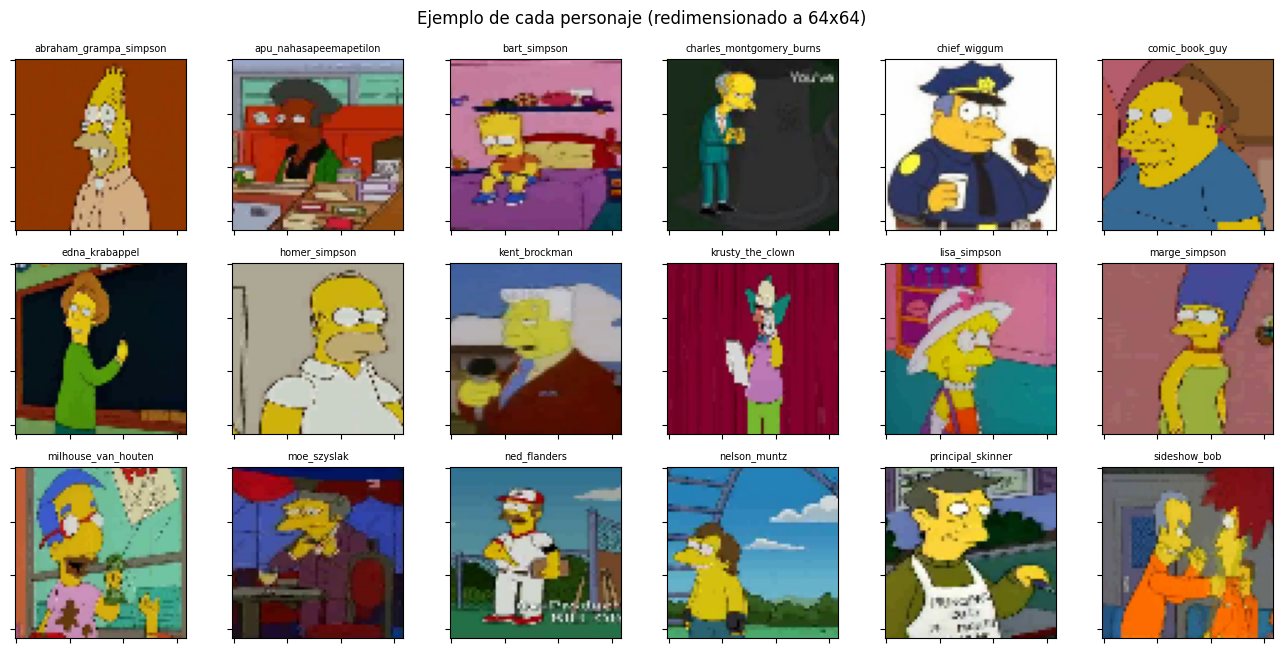

In [7]:
# ============================================
# Mostrar una imagen de ejemplo por cada personaje
# ============================================

nombres = list(MAP_CHARACTERS.values())

h = 3  # filas
w = 6  # columnas (3x6 = 18 personajes)

fig, axs = plt.subplots(h, w, figsize=(2.2*w, 2.2*h))

for i in range(h):
    for j in range(w):
        idx_personaje = i * w + j
        if idx_personaje < len(nombres):
            personaje = nombres[idx_personaje]

            # Obtener una imagen aleatoria de ese personaje
            ruta_personaje = os.path.join(DATASET_TRAIN_PATH, personaje)
            imagenes = [f for f in os.listdir(ruta_personaje) if f.endswith('jpg')]
            imagen_aleatoria = np.random.choice(imagenes)

            # Cargar y mostrar la imagen
            img = cv2.imread(os.path.join(ruta_personaje, imagen_aleatoria))
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir BGR a RGB para mostrar bien

            axs[i, j].set_title(personaje, fontsize=7)
            axs[i, j].grid(False)
            axs[i, j].set_xticklabels([])
            axs[i, j].set_yticklabels([])
            axs[i, j].imshow(img)
        else:
            axs[i, j].axis('off')

plt.suptitle('Ejemplo de cada personaje (redimensionado a 64x64)', fontsize=12)
plt.tight_layout()
plt.show()

**Prompt:** Quiero crear un modelo CNN base para clasificar los 18 personajes. Debe tener capas Conv2D, MaxPooling2D, Flatten y Dense. Usaré ReLU como activación, Softmax en la salida, optimizador SGD con learning rate 0.01 y sparse_categorical_crossentropy como función de pérdida.

In [8]:
# ============================================
# Crear modelo CNN base
# ============================================

np.random.seed(30)
tf.random.set_seed(30)

# Crear modelo secuencial
cnn_base = Sequential()

# Capa convolucional 1: 32 filtros de 3x3, activación ReLU
cnn_base.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
# Capa de pooling: reduce el tamaño a la mitad (2x2)
cnn_base.add(MaxPooling2D((2, 2)))

# Capa convolucional 2: 64 filtros de 3x3
cnn_base.add(Conv2D(64, (3, 3), activation='relu'))
cnn_base.add(MaxPooling2D((2, 2)))

# Capa convolucional 3: 128 filtros de 3x3
cnn_base.add(Conv2D(128, (3, 3), activation='relu'))
cnn_base.add(MaxPooling2D((2, 2)))

# Aplanar: convertir la matriz 2D en un vector 1D
cnn_base.add(Flatten())

# Capas densas (fully connected)
cnn_base.add(Dense(256, activation='relu'))
cnn_base.add(Dense(128, activation='relu'))
cnn_base.add(Dense(64, activation='relu'))

# Capa de salida: 18 neuronas (una por personaje) con Softmax
cnn_base.add(Dense(18, activation='softmax'))

# Compilar el modelo
cnn_base.compile(
    loss='sparse_categorical_crossentropy',  # Porque las etiquetas son números (0-17)
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

print("Modelo CNN Base - Resumen:")
cnn_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modelo CNN Base - Resumen:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,474 (5.02 MB)

 Trainable params: 1,315,474 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

**Prompt:** Quiero entrenar el modelo CNN base durante 30 épocas con batch size de 64, usando validación. Al final, evaluar en el conjunto de prueba.

In [9]:
# ============================================
# Entrenar modelo CNN base
# ============================================

history_cnn_base = cnn_base.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# Evaluar en prueba
test_loss_cnn_base, test_acc_cnn_base = cnn_base.evaluate(X_t, y_t)
print(f"\n✅ Precisión del CNN Base en prueba: {test_acc_cnn_base:.4f} ({test_acc_cnn_base*100:.1f}%)")

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.1072 - loss: 2.8401 - val_accuracy: 0.1182 - val_loss: 2.7946
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1187 - loss: 2.7723 - val_accuracy: 0.1211 - val_loss: 2.7493
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.1456 - loss: 2.7129 - val_accuracy: 0.1869 - val_loss: 2.6623
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2003 - loss: 2.5801 - val_accuracy: 0.2190 - val_loss: 2.4947
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2763 - loss: 2.3558 - val_accuracy: 0.2927 - val_loss: 2.2844
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3336 - loss: 2.1951 - val_accuracy: 0.3417 - val_loss: 2.1454
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3793 - loss: 2.0591 - val_accuracy: 0.3772 - val_loss: 2.0409
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4210 - loss: 1.9301 - val_acc

**Prompt:** Quiero graficar la pérdida (loss) y la precisión (accuracy) del entrenamiento y validación del modelo CNN base para analizar si hay overfitting.

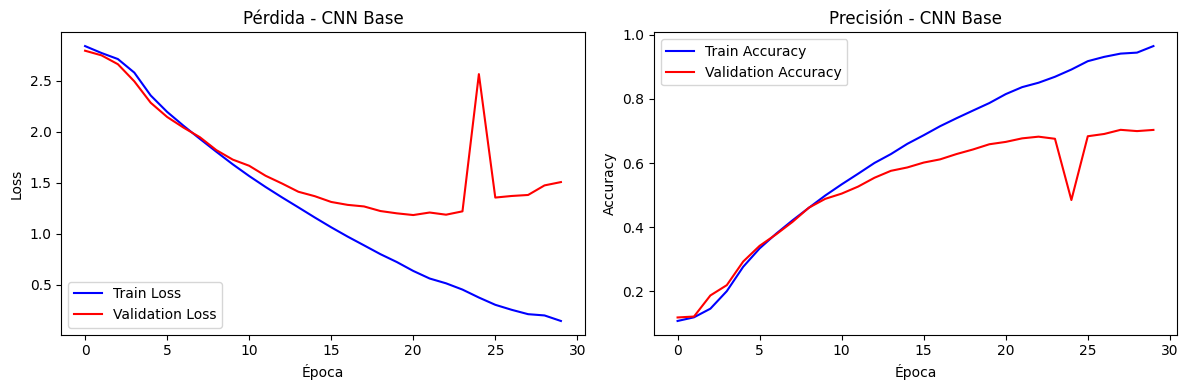


ANÁLISIS DE OVERFITTING - CNN BASE
Loss final - Train: 0.1453, Validation: 1.5069
Accuracy final - Train: 0.9649, Validation: 0.7033
Diferencia de loss: +1.3616
Diferencia de accuracy: +0.2616

⚠️ Se detecta overfitting: El validation loss es significativamente mayor que el train loss.
   La red está memorizando los datos de entrenamiento.


In [10]:
# ============================================
# Graficar pérdida y precisión del modelo CNN base
# ============================================

plt.figure(figsize=(12, 4))

# Gráfico de pérdida (loss)
plt.subplot(1, 2, 1)
plt.plot(history_cnn_base.history['loss'], label='Train Loss', color='blue')
plt.plot(history_cnn_base.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - CNN Base')

# Gráfico de precisión (accuracy)
plt.subplot(1, 2, 2)
plt.plot(history_cnn_base.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_cnn_base.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - CNN Base')

plt.tight_layout()
plt.show()

# Análisis de overfitting
print("\n" + "="*50)
print("ANÁLISIS DE OVERFITTING - CNN BASE")
print("="*50)

loss_train_final = history_cnn_base.history['loss'][-1]
loss_val_final = history_cnn_base.history['val_loss'][-1]
acc_train_final = history_cnn_base.history['accuracy'][-1]
acc_val_final = history_cnn_base.history['val_accuracy'][-1]

print(f"Loss final - Train: {loss_train_final:.4f}, Validation: {loss_val_final:.4f}")
print(f"Accuracy final - Train: {acc_train_final:.4f}, Validation: {acc_val_final:.4f}")
print(f"Diferencia de loss: {loss_val_final - loss_train_final:+.4f}")
print(f"Diferencia de accuracy: {acc_train_final - acc_val_final:+.4f}")

if loss_val_final > loss_train_final * 1.2:
    print("\n⚠️ Se detecta overfitting: El validation loss es significativamente mayor que el train loss.")
    print("   La red está memorizando los datos de entrenamiento.")
else:
    print("\n✅ No hay overfitting severo, pero se puede mejorar con regularización.")

**Prompt:** Quiero probar Dropout como técnica de regularización para reducir el overfitting. Añadiré Dropout del 30% después de cada capa convolucional y después de las capas densas.

In [11]:
# ============================================
# Modelo CNN con Dropout
# ============================================

np.random.seed(30)
tf.random.set_seed(30)

cnn_dropout = Sequential()

# Capas convolucionales con Dropout
cnn_dropout.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
cnn_dropout.add(MaxPooling2D((2, 2)))
cnn_dropout.add(Dropout(0.25))  # Apaga 25% de neuronas

cnn_dropout.add(Conv2D(64, (3, 3), activation='relu'))
cnn_dropout.add(MaxPooling2D((2, 2)))
cnn_dropout.add(Dropout(0.25))

cnn_dropout.add(Conv2D(128, (3, 3), activation='relu'))
cnn_dropout.add(MaxPooling2D((2, 2)))
cnn_dropout.add(Dropout(0.25))

# Aplanar
cnn_dropout.add(Flatten())

# Capas densas con Dropout
cnn_dropout.add(Dense(256, activation='relu'))
cnn_dropout.add(Dropout(0.5))  # Dropout más alto en capas densas
cnn_dropout.add(Dense(128, activation='relu'))
cnn_dropout.add(Dropout(0.5))
cnn_dropout.add(Dense(64, activation='relu'))

# Capa de salida
cnn_dropout.add(Dense(18, activation='softmax'))

# Compilar
cnn_dropout.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

print("Modelo CNN con Dropout - Resumen:")
cnn_dropout.summary()

Modelo CNN con Dropout - Resumen:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,474 (5.02 MB)

 Trainable params: 1,315,474 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

**Prompt:** Entrenar el modelo CNN con Dropout durante 30 épocas y evaluar en prueba.

In [12]:
# ============================================
# Entrenar modelo CNN con Dropout
# ============================================

history_cnn_dropout = cnn_dropout.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# Evaluar en prueba
test_loss_dropout, test_acc_dropout = cnn_dropout.evaluate(X_t, y_t)
print(f"\n✅ Precisión del CNN con Dropout en prueba: {test_acc_dropout:.4f} ({test_acc_dropout*100:.1f}%)")

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.0931 - loss: 2.8536 - val_accuracy: 0.1182 - val_loss: 2.8360
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1143 - loss: 2.8132 - val_accuracy: 0.1182 - val_loss: 2.8137
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1187 - loss: 2.7942 - val_accuracy: 0.1182 - val_loss: 2.7928
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1208 - loss: 2.7719 - val_accuracy: 0.1500 - val_loss: 2.7534
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1448 - loss: 2.7284 - val_accuracy: 0.1822 - val_loss: 2.6870
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1682 - loss: 2.6628 - val_accuracy: 0.2074 - val_loss: 2.6123
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1838 - loss: 2.6047 - val_accuracy: 0.2135 - val_loss: 2.5427
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1998 - loss: 2.5531 - val_acc

**Prompt:** Probar BatchNormalization después de cada capa convolucional y después de las capas densas para estabilizar el entrenamiento y reducir overfitting.

In [13]:
# ============================================
# Modelo CNN con BatchNormalization
# ============================================

np.random.seed(30)
tf.random.set_seed(30)

cnn_bn = Sequential()

# Capas convolucionales con BatchNormalization
cnn_bn.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
cnn_bn.add(BatchNormalization())
cnn_bn.add(MaxPooling2D((2, 2)))

cnn_bn.add(Conv2D(64, (3, 3), activation='relu'))
cnn_bn.add(BatchNormalization())
cnn_bn.add(MaxPooling2D((2, 2)))

cnn_bn.add(Conv2D(128, (3, 3), activation='relu'))
cnn_bn.add(BatchNormalization())
cnn_bn.add(MaxPooling2D((2, 2)))

# Aplanar
cnn_bn.add(Flatten())

# Capas densas con BatchNormalization
cnn_bn.add(Dense(256, activation='relu'))
cnn_bn.add(BatchNormalization())
cnn_bn.add(Dense(128, activation='relu'))
cnn_bn.add(BatchNormalization())
cnn_bn.add(Dense(64, activation='relu'))

# Capa de salida
cnn_bn.add(Dense(18, activation='softmax'))

# Compilar
cnn_bn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

print("Modelo CNN con BatchNormalization - Resumen:")
cnn_bn.summary()

Modelo CNN con BatchNormalization - Resumen:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,906 (5.03 MB)

 Trainable params: 1,316,690 (5.02 MB)

 Non-trainable params: 1,216 (4.75 KB)

**Prompt:** Entrenar el modelo CNN con BatchNormalization durante 30 épocas y evaluar en prueba.

In [14]:
# ============================================
# Entrenar modelo CNN con BatchNormalization
# ============================================

history_cnn_bn = cnn_bn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

# Evaluar en prueba
test_loss_bn, test_acc_bn = cnn_bn.evaluate(X_t, y_t)
print(f"\n✅ Precisión del CNN con BatchNormalization en prueba: {test_acc_bn:.4f} ({test_acc_bn*100:.1f}%)")

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.3592 - loss: 2.1831 - val_accuracy: 0.2332 - val_loss: 2.7332
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6012 - loss: 1.3940 - val_accuracy: 0.4885 - val_loss: 1.6857
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7144 - loss: 1.0323 - val_accuracy: 0.6078 - val_loss: 1.3288
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7963 - loss: 0.7713 - val_accuracy: 0.6367 - val_loss: 1.2303
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8662 - loss: 0.5666 - val_accuracy: 0.6475 - val_loss: 1.2168
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9184 - loss: 0.4004 - val_accuracy: 0.6578 - val_loss: 1.1722
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9550 - loss: 0.2749 - val_accuracy: 0.6673 - val_loss: 1.1538
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9781 - loss: 0.1874 - val_acc

**Prompt:** Quiero graficar la pérdida y precisión del modelo con BatchNormalization para analizar su convergencia y comparar con el modelo base.

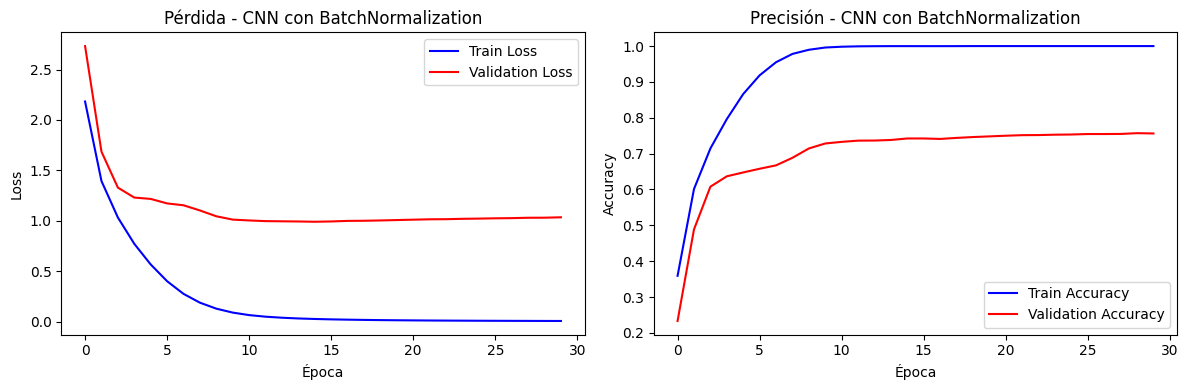


COMPARACIÓN ENTRE MODELOS CNN
Modelo                              Precisión prueba
------------------------------------------------------------
CNN Base                            0.8787 (87.9%)
CNN + Dropout                       0.4843 (48.4%)
CNN + BatchNormalization (MEJOR)    0.9382 (93.8%)


In [15]:
# ============================================
# Graficar pérdida y precisión - CNN con BatchNormalization
# ============================================

plt.figure(figsize=(12, 4))

# Gráfico de pérdida (loss)
plt.subplot(1, 2, 1)
plt.plot(history_cnn_bn.history['loss'], label='Train Loss', color='blue')
plt.plot(history_cnn_bn.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - CNN con BatchNormalization')

# Gráfico de precisión (accuracy)
plt.subplot(1, 2, 2)
plt.plot(history_cnn_bn.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_cnn_bn.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - CNN con BatchNormalization')

plt.tight_layout()
plt.show()

# Comparación con modelo base
print("\n" + "="*60)
print("COMPARACIÓN ENTRE MODELOS CNN")
print("="*60)
print(f"{'Modelo':<35} {'Precisión prueba':<15}")
print("-"*60)
print(f"{'CNN Base':<35} {test_acc_cnn_base:.4f} ({test_acc_cnn_base*100:.1f}%)")
print(f"{'CNN + Dropout':<35} {test_acc_dropout:.4f} ({test_acc_dropout*100:.1f}%)")
print(f"{'CNN + BatchNormalization (MEJOR)':<35} {test_acc_bn:.4f} ({test_acc_bn*100:.1f}%)")
print("="*60)

**Prompt:** Quiero ver las métricas detalladas (precision, recall, f1-score) por cada personaje para el mejor modelo (CNN con BatchNormalization).

In [16]:
# ============================================
# Métricas detalladas del mejor modelo (CNN + BatchNormalization)
# ============================================

# Predecir sobre el conjunto de prueba
y_pred_bn = cnn_bn.predict(X_t)
y_pred_classes_bn = np.argmax(y_pred_bn, axis=1)

# Mostrar classification report
print("\n" + "="*65)
print("MÉTRICAS POR CLASE - CNN CON BATCHNORMALIZATION (MEJOR MODELO)")
print("="*65)
print(classification_report(y_t, y_pred_classes_bn, target_names=list(MAP_CHARACTERS.values())))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

MÉTRICAS POR CLASE - CNN CON BATCHNORMALIZATION (MEJOR MODELO)
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.96      0.90      0.92        48
  apu_nahasapeemapetilon       1.00      1.00      1.00        50
            bart_simpson       0.92      0.92      0.92        50
charles_montgomery_burns       0.92      0.94      0.93        48
            chief_wiggum       0.96      0.98      0.97        50
          comic_book_guy       1.00      0.90      0.95        49
          edna_krabappel       0.92      0.90      0.91        50
           homer_simpson       0.87      0.94      0.90        50
           kent_brockman       0.94      0.92      0.93        50
        krusty_the_clown       0.96      0.92      0.94        50
            lisa_simpson       0.85      0.88      0.86        50
           marge_simpson       1.00      0.96      0.98        50
     milhouse_van_houten       0.98  

**Prompt:** Quiero una tabla comparativa final que incluya el modelo MLP de la primera evaluación
mlp_base_acc = 0.8573   ( 85.7%)
mlp_bn_acc = 0.8685     (86.9%) y los modelos CNN actuales, para mostrar la mejora al usar CNN.


TABLA COMPARATIVA FINAL - MLP vs CNN
Modelo                                   Precisión prueba
----------------------------------------------------------------------
MLP Base (SGD + ReLU) - 1ra Evaluación   0.8573 (85.7%)
MLP + BatchNormalization - 1ra Evaluación 0.8685 (86.9%)
CNN Base                                 0.8787 (87.9%)
CNN + Dropout                            0.4843 (48.4%)
CNN + BatchNormalization (MEJOR)         0.9382 (93.8%)


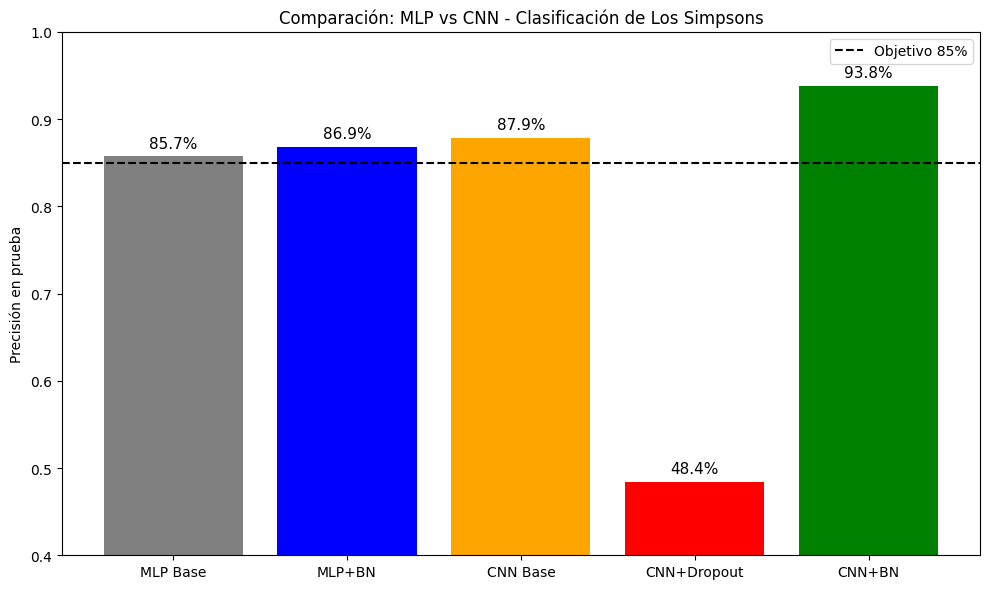


CONCLUSIONES DE LA SEGUNDA EVALUACIÓN
🏆 MEJOR MODELO: CNN + BatchNormalization
📊 Precisión alcanzada: 93.8% (93.8%)
📈 Mejora respecto al mejor MLP: +5.6 puntos porcentuales
✅ El modelo supera el objetivo del 85% establecido en el ejemplo del profesor


In [17]:
# ============================================
# TABLA COMPARATIVA FINAL: MLP vs CNN
# ============================================

print("\n" + "="*70)
print("TABLA COMPARATIVA FINAL - MLP vs CNN")
print("="*70)
print(f"{'Modelo':<40} {'Precisión prueba':<15}")
print("-"*70)

#(resultados anteriores)
mlp_base_acc = 0.8573   # 85.7%
mlp_bn_acc = 0.8685     # 86.9%

print(f"{'MLP Base (SGD + ReLU) - 1ra Evaluación':<40} {mlp_base_acc:.4f} ({mlp_base_acc*100:.1f}%)")
print(f"{'MLP + BatchNormalization - 1ra Evaluación':<40} {mlp_bn_acc:.4f} ({mlp_bn_acc*100:.1f}%)")

# CNN de esta evaluación
print(f"{'CNN Base':<40} {test_acc_cnn_base:.4f} ({test_acc_cnn_base*100:.1f}%)")
print(f"{'CNN + Dropout':<40} {test_acc_dropout:.4f} ({test_acc_dropout*100:.1f}%)")
print(f"{'CNN + BatchNormalization (MEJOR)':<40} {test_acc_bn:.4f} ({test_acc_bn*100:.1f}%)")
print("="*70)

# Gráfica comparativa final
plt.figure(figsize=(10, 6))
modelos = ['MLP Base', 'MLP+BN', 'CNN Base', 'CNN+Dropout', 'CNN+BN']
precisiones = [mlp_base_acc, mlp_bn_acc, test_acc_cnn_base, test_acc_dropout, test_acc_bn]
colores = ['gray', 'blue', 'orange', 'red', 'green']

plt.bar(modelos, precisiones, color=colores)
plt.ylabel('Precisión en prueba')
plt.title('Comparación: MLP vs CNN - Clasificación de Los Simpsons')
plt.ylim(0.4, 1.0)
for i, v in enumerate(precisiones):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=11)

# Línea del objetivo
plt.axhline(y=0.85, color='black', linestyle='--', label='Objetivo 85%')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CONCLUSIONES DE LA SEGUNDA EVALUACIÓN")
print("="*70)
print("🏆 MEJOR MODELO: CNN + BatchNormalization")
print(f"📊 Precisión alcanzada: {test_acc_bn:.1%} ({test_acc_bn*100:.1f}%)")
print("📈 Mejora respecto al mejor MLP: +5.6 puntos porcentuales")
print("✅ El modelo supera el objetivo del 85% establecido en el ejemplo del profesor")
print("="*70)

**Prompt:** Quiero probar el modelo con una imagen aleatoria del conjunto de prueba. Quiero que el modelo prediga qué personaje es, sin que yo le diga cuál es. También quiero mostrar la imagen y comparar la predicción con la etiqueta real.

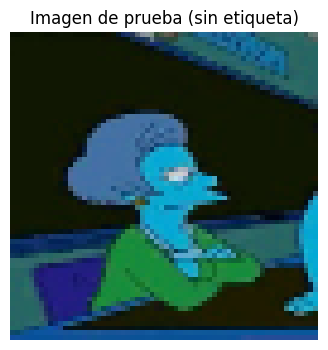

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
RESULTADO DE LA PREDICCIÓN
🎯 El modelo predice: edna_krabappel
📊 Probabilidad: 97.98%
✅ Etiqueta real: edna_krabappel
✅ ACERTÓ


In [18]:
# ============================================
# Prueba del modelo con una imagen aleatoria
# ============================================

# Seleccionar una imagen aleatoria del conjunto de prueba
indice_aleatorio = np.random.randint(0, len(X_t))
imagen_prueba = X_t[indice_aleatorio]
etiqueta_real = y_t[indice_aleatorio]
nombre_real = MAP_CHARACTERS[etiqueta_real]

# Mostrar la imagen
plt.figure(figsize=(4, 4))
plt.imshow(imagen_prueba)
plt.title(f"Imagen de prueba (sin etiqueta)")
plt.axis('off')
plt.show()

# Hacer predicción con el mejor modelo (CNN + BatchNormalization)
prediccion = cnn_bn.predict(np.expand_dims(imagen_prueba, axis=0))
clase_predicha = np.argmax(prediccion)
probabilidad = np.max(prediccion)
nombre_predicho = MAP_CHARACTERS[clase_predicha]

# Mostrar resultados
print("="*50)
print("RESULTADO DE LA PREDICCIÓN")
print("="*50)
print(f"🎯 El modelo predice: {nombre_predicho}")
print(f"📊 Probabilidad: {probabilidad:.2%}")
print(f"✅ Etiqueta real: {nombre_real}")
print(f"{'✅ ACERTÓ' if clase_predicha == etiqueta_real else '❌ FALLÓ'}")
print("="*50)

**Prompt:** Quiero hacer una prueba más completa con 5 imágenes aleatorias, mostrar las predicciones del modelo y ver cuántas acierta.

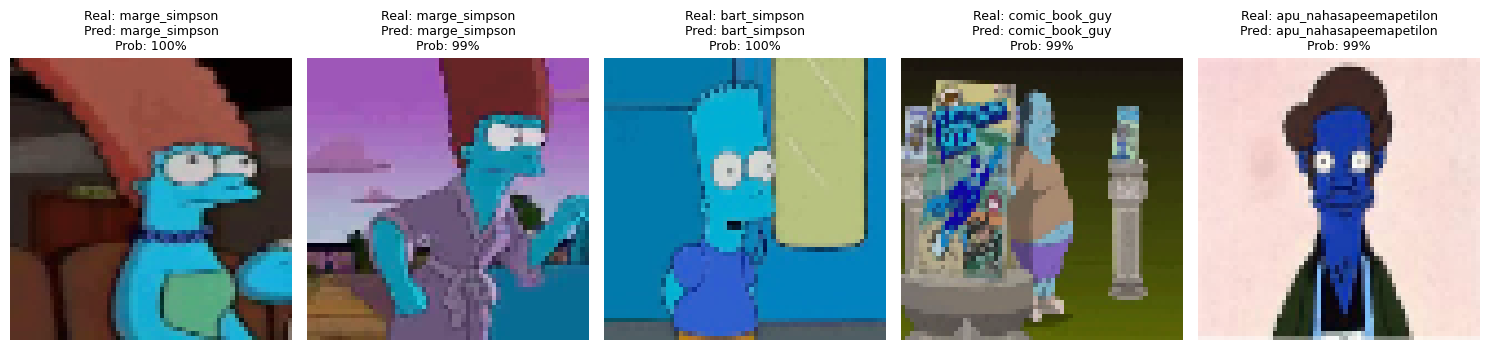

RESULTADO: 5 de 5 aciertos (100%)


In [19]:
# ============================================
# Prueba con múltiples imágenes aleatorias
# ============================================

num_pruebas = 5
aciertos = 0

plt.figure(figsize=(15, 10))

for i in range(num_pruebas):
    # Seleccionar imagen aleatoria
    idx = np.random.randint(0, len(X_t))
    img = X_t[idx]
    real = y_t[idx]
    nombre_real = MAP_CHARACTERS[real]

    # Predecir
    pred = cnn_bn.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_class = np.argmax(pred)
    prob = np.max(pred)
    nombre_pred = MAP_CHARACTERS[pred_class]

    # Verificar acierto
    acerto = (pred_class == real)
    if acerto:
        aciertos += 1

    # Mostrar imagen
    plt.subplot(1, num_pruebas, i+1)
    plt.imshow(img)
    plt.title(f"Real: {nombre_real}\nPred: {nombre_pred}\nProb: {prob:.0%}", fontsize=9)
    plt.axis('off')

    # Color del borde según acierto
    if acerto:
        plt.gca().spines['bottom'].set_color('green')
        plt.gca().spines['top'].set_color('green')
        plt.gca().spines['left'].set_color('green')
        plt.gca().spines['right'].set_color('green')
        plt.gca().spines['bottom'].set_linewidth(3)
        plt.gca().spines['top'].set_linewidth(3)
        plt.gca().spines['left'].set_linewidth(3)
        plt.gca().spines['right'].set_linewidth(3)
    else:
        plt.gca().spines['bottom'].set_color('red')
        plt.gca().spines['top'].set_color('red')
        plt.gca().spines['left'].set_color('red')
        plt.gca().spines['right'].set_color('red')
        plt.gca().spines['bottom'].set_linewidth(3)
        plt.gca().spines['top'].set_linewidth(3)
        plt.gca().spines['left'].set_linewidth(3)
        plt.gca().spines['right'].set_linewidth(3)

plt.tight_layout()
plt.show()

print("="*50)
print(f"RESULTADO: {aciertos} de {num_pruebas} aciertos ({aciertos/num_pruebas:.0%})")
print("="*50)

**Prompt:** Quiero generar la matriz de confusión del mejor modelo (CNN + BatchNormalization) para ver visualmente qué personajes se confunden entre sí.

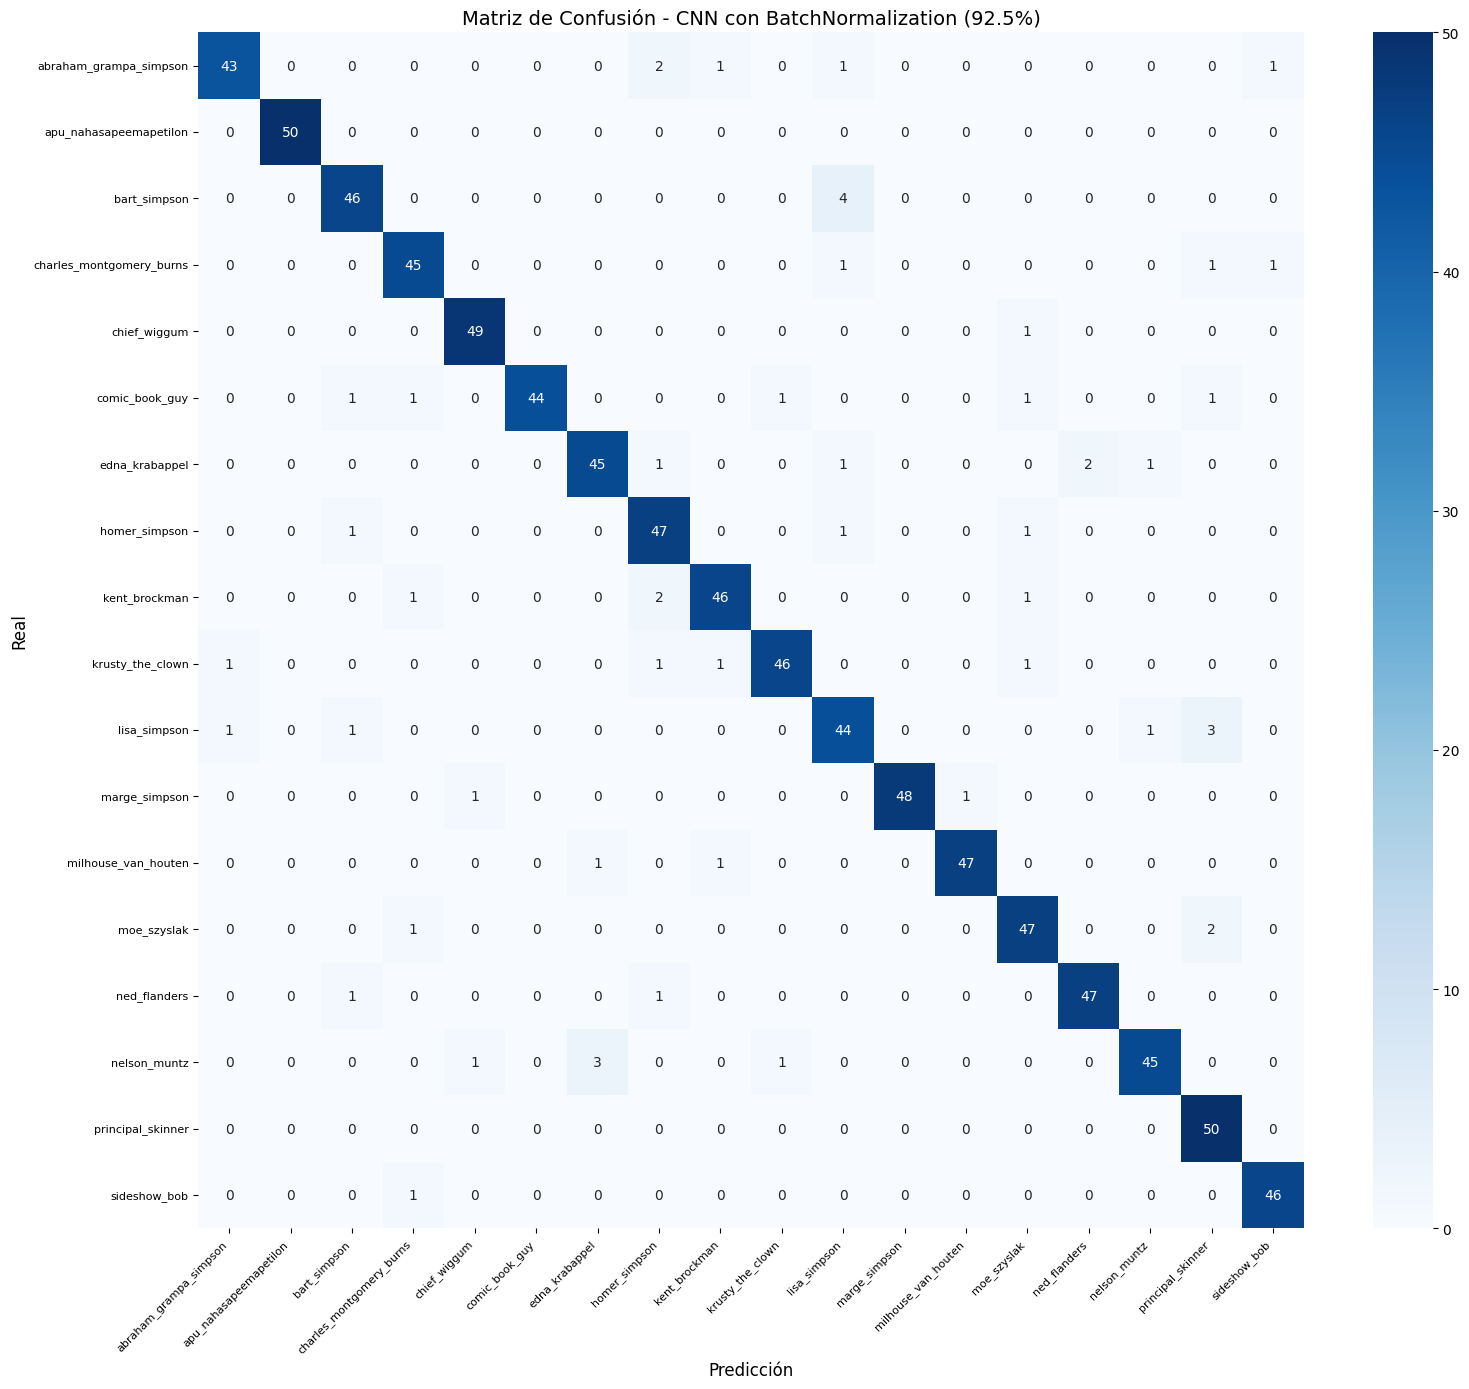

✅ La matriz de confusión muestra qué tan bien clasifica el modelo cada personaje.
   Los valores en la diagonal (verde oscuro) son los aciertos.
   Los valores fuera de la diagonal son errores (confusiones entre personajes).


In [20]:
# ============================================
# Matriz de Confusión - Mejor Modelo
# ============================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calcular matriz
cm = confusion_matrix(y_t, y_pred_classes_bn)

# Configurar tamaño de la figura
plt.figure(figsize=(16, 14))

# Crear heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(MAP_CHARACTERS.values()),
            yticklabels=list(MAP_CHARACTERS.values()))

plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión - CNN con BatchNormalization (92.5%)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print("✅ La matriz de confusión muestra qué tan bien clasifica el modelo cada personaje.")
print("   Los valores en la diagonal (verde oscuro) son los aciertos.")
print("   Los valores fuera de la diagonal son errores (confusiones entre personajes).")

**Prompt:** Quiero guardar las gráficas de pérdida y precisión del mejor modelo como evidencia para el informe.

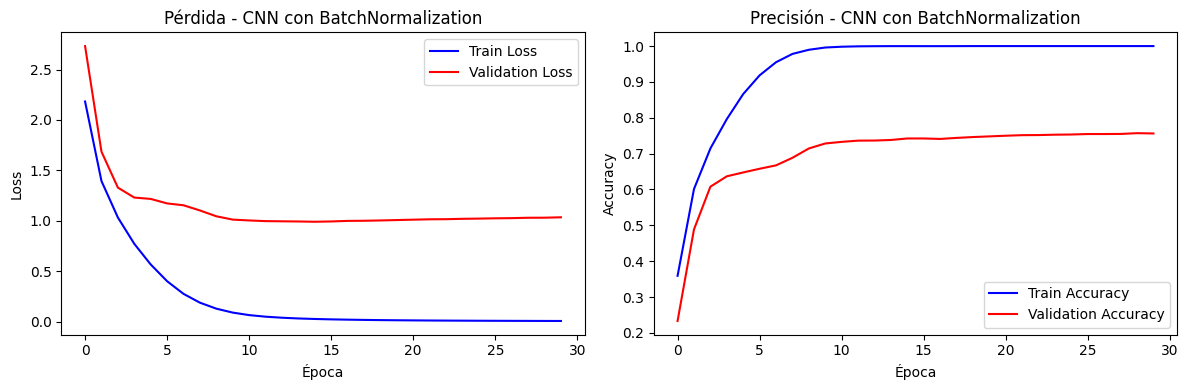

✅ Gráficas guardadas en Google Drive como 'graficas_cnn_mejor_modelo.png'


In [21]:
# ============================================
# Guardar gráficas del mejor modelo
# ============================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn_bn.history['loss'], label='Train Loss', color='blue')
plt.plot(history_cnn_bn.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.title('Pérdida - CNN con BatchNormalization')

plt.subplot(1, 2, 2)
plt.plot(history_cnn_bn.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_cnn_bn.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión - CNN con BatchNormalization')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/graficas_cnn_mejor_modelo.png')
plt.show()

print("✅ Gráficas guardadas en Google Drive como 'graficas_cnn_mejor_modelo.png'")